<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Heat%20Transfer/E_20_103_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Design Data:**
* **Number of milk containers collected per day:** 40
* **Weight of an empty container:** 2 kg
* **Weight of milk in a container:** 5 kg
* **Specific heat capacity of the container material:** 921.1 J/kg·K
* **Specific heat capacity of milk:** 4000 J/kg·K

As the engineering team, the goal is to assess the appropriateness of the existing Air Conditioning unit in the Heat Engine Laboratory for this application through the following steps:

1.  Develop a method to evaluate the viability of the current unit.
2.  Perform tests using the laboratory cooling system to gather essential performance metrics.
3.  Identify the necessary upgrades or alterations if the capacity needs to be expanded to accommodate 80 milk containers daily.
4.  Prepare a detailed report summarizing the results and engineering suggestions.

### Cooling Load Calculation for Milk Storage

### 1. System Parameters
* **Number of containers ($n$):** 40
* **Mass of milk per container ($m_m$):** 5 kg
* **Mass of empty container ($m_c$):** 2 kg
* **Specific heat of milk ($c_m$):** $4000\text{ J/kg}\cdot\text{K}$
* **Specific heat of aluminum ($c_c$):** $921.1\text{ J/kg}\cdot\text{K}$
* **Target temperature ($T_f$):** $15^\circ\text{C}$
* **Cooling time ($t$):** 2 hours ($7200\text{ seconds}$)

---

### 2. Case A: Average Initial Temperature ($T_i = 37.5^\circ\text{C}$)
*Calculated for the $35^\circ\text{C} - 40^\circ\text{C}$ range.*

**Total Heat Removal ($Q$):**
$$Q = n \times [(m_m \cdot c_m + m_c \cdot c_c) \times (T_i - T_f)]$$
$$Q = 40 \times [(5 \cdot 4000 + 2 \cdot 921.1) \times (37.5 - 15)]$$
$$Q = 19,657,980\text{ J} \approx 19.66\text{ MJ}$$

**Required Cooling Load ($\dot{Q}$):**
$$\dot{Q} = \frac{Q}{t} = \frac{19,657,980}{7200}$$
**$$\dot{Q}_{avg} \approx 2.73\text{ kW}$$**

---

### 3. Case B: Maximum Initial Temperature ($T_i = 40^\circ\text{C}$)
*Calculated for the worst-case scenario.*

**Total Heat Removal ($Q$):**
$$Q = 40 \times [(5 \cdot 4000 + 2 \cdot 921.1) \times (40 - 15)]$$
$$Q = 21,842,200\text{ J} \approx 21.84\text{ MJ}$$

**Required Cooling Load ($\dot{Q}$):**
$$\dot{Q} = \frac{Q}{t} = \frac{21,842,200}{7200}$$
**$$\dot{Q}_{max} \approx 3.03\text{ kW}$$**

In [43]:
# Parameters for the cooling load calculation
# These parameters are based on the laboratory problem statement and design data.
n_containers = 40          # Number of milk containers
m_container = 2            # Weight of an empty container (kg)
m_milk = 5                 # Weight of milk per container (kg)
cp_container = 921.1       # Specific heat capacity of container material (J/kgK)
cp_milk = 4000.0           # Specific heat capacity of milk (J/kgK)
t_target = 15.0            # Target storage temperature (°C)
cooling_time_hours = 2     # Required cooling duration (hours)

# Convert cooling time from hours to seconds for calculations
cooling_time_sec = cooling_time_hours * 3600

def calculate_load(t_initial):
    """
    Calculates the required cooling load in kilowatts (kW)
    for a given initial temperature of the milk and containers.
    """
    # Calculate total heat to be removed from milk and containers
    # Q = m * cp * Delta_T
    q_milk = n_containers * (m_milk * cp_milk * (t_initial - t_target))
    q_container = n_containers * (m_container * cp_container * (t_initial - t_target))

    total_q_joules = q_milk + q_container

    # Calculate cooling load (power) by dividing total energy by time
    load_watts = total_q_joules / cooling_time_sec
    return load_watts / 1000  # Convert Watts to Kilowatts

# Define initial temperature scenarios based on problem statement range (35°C - 40°C)
t_avg = (35 + 40) / 2  # Average initial temperature
t_max = 40.0           # Maximum (worst-case) initial temperature

# Calculate cooling loads for both scenarios
load_avg = calculate_load(t_avg)
load_max = calculate_load(t_max)

# Display the calculated cooling load results with improved formatting
print("════════════════════════════════════════")
print(" Cooling Load Calculation Summary       ")
print("════════════════════════════════════════")
print(f"Scenario 1: Average Initial Temperature ({t_avg}°C)")
print(f"  Required Cooling Load: {load_avg:10.3f} kW")
print(f"\nScenario 2: Maximum Initial Temperature ({t_max}°C)")
print(f"  Required Cooling Load: {load_max:10.3f} kW")
print("════════════════════════════════════════")

════════════════════════════════════════
 Cooling Load Calculation Summary       
════════════════════════════════════════
Scenario 1: Average Initial Temperature (37.5°C)
  Required Cooling Load:      2.730 kW

Scenario 2: Maximum Initial Temperature (40.0°C)
  Required Cooling Load:      3.034 kW
════════════════════════════════════════


## THEORY

### 1. Measurement Variables
For system evaluation, record these physical and thermodynamic quantities:

* **Duct Dimensions:** Determine the width ($w$) and height ($h$) of the air inlet duct to compute the cross-sectional area ($A = w \times h$).
* **Air Speed ($v$):** Employ an anemometer to gauge air velocity at the inlet. Take several measurements and average them to compensate for uneven airflow.
* **Psychrometric Conditions:** Record the **Dry Bulb Temperature ($T_{db}$)** and **Wet Bulb Temperature ($T_{wb}$)** at:
    * **State 1 (Inlet):** Ambient air entering the evaporator.
    * **State 2 (Outlet):** Cooled air leaving the evaporator.

---

### 2. Psychrometric Principles
The effective cooling capacity relies on the moist air properties. As air comprises dry air and water vapor, its total energy content (enthalpy) combines sensible heat (from temperature variation) and latent heat (from moisture phase transition).



**Vapor Pressure and Humidity Ratio:**
To calculate specific enthalpy ($h$), first compute the humidity ratio ($\omega$), indicating water vapor mass per unit mass of dry air. Use the saturation vapor pressure ($P_{swb}$) at wet bulb temperature with the Magnus-Tetens formula:
$$P_{swb} = 0.61078 \exp\left(\frac{17.27 \cdot T_{wb}}{T_{wb} + 237.3}\right)$$
The true vapor pressure ($P_v$) accounts for the wet-dry bulb depression:
$$P_v = P_{swb} - 0.000662 \cdot P_{atm} \cdot (T_{db} - T_{wb})$$
Then, obtain the humidity ratio ($\omega$):
$$\omega = 0.62194 \cdot \frac{P_v}{P_{atm} - P_v}$$

**Specific Enthalpy Formula:**
Total enthalpy ($h$) in kJ/kg follows this energy equation:
$$h = c_{pa} T_{db} + \omega (h_{fg} + c_{pv} T_{db})$$
Where:
* $c_{pa} \approx 1.006 \text{ kJ/kg}\cdot\text{K}$ (Specific heat of dry air)
* $h_{fg} \approx 2501 \text{ kJ/kg}$ (Enthalpy of vaporization at $0^\circ\text{C}$)
* $c_{pv} \approx 1.86 \text{ kJ/kg}\cdot\text{K}$ (Specific heat of water vapor)

---

### 3. Thermodynamic Computations
Unit performance stems from the enthalpy difference in the air flow through the evaporator.



**Air Mass Flow Rate ($\dot{m}_a$):**
$$\dot{m}_a = \rho \cdot A \cdot v$$
*Where $\rho \approx 1.2 \text{ kg/m}^3$ (air density at standard conditions).*

**Actual Cooling Capacity ($\dot{Q}_{act}$):**
Heat extraction rate equals mass flow times enthalpy reduction across the evaporator:
$$\dot{Q}_{act} = \dot{m}_a \times (h_{in} - h_{out})$$

---

### 4. Data Recording Table

| Parameter | Symbol | Unit | Value |
| :--- | :--- | :--- | :--- |
| Duct Area | $A$ | $m^2$ | |
| Avg. Air Velocity | $v$ | $m/s$ | |
| Inlet Enthalpy | $h_{in}$ | $kJ/kg$ | |
| Outlet Enthalpy | $h_{out}$ | $kJ/kg$ | |
| **Actual Cooling Capacity** | **$\dot{Q}_{act}$** | **kW** | |

---

### 5. Suitability Standards
The unit qualifies if its measured capacity satisfies the peak load under factory conditions:
* **Required Load (Max):** $3.03 \text{ kW}$
* **Evaluation Rule:**
    * If $\dot{Q}_{act} \geq 3.03 \text{ kW}$: **Adequate.**
    * If $\dot{Q}_{act} < 3.03 \text{ kW}$: **Inadequate; modifications needed.**

## OBSERVATIONS


### 1. Column Descriptions (Nomenclature)
For accurate data interpretation, temperature sensors are identified as:
* **$D_1$**: internal diameter of return air duct (m)
* **$D_1$**: internal diameter of cool air inlet duct (m)
* **$T_1$**: Return air dry bulb temperature ($^\circ$C)
* **$T_2$**: Return air wet bulb temperature ($^\circ$C)
* **$T_3$**: Evaporator inlet dry bulb temperature ($^\circ$C)
* **$T_4$**: Evaporator inlet wet bulb temperature ($^\circ$C)
* **$T_5$**: Evaporator exit dry bulb temperature ($^\circ$C)
* **$T_6$**: Evaporator exit wet bulb temperature ($^\circ$C)
* **$V_{in}$ / $V_{out}$**: Air velocity at intake and exit (m/s)

---

### 2. Recorded Experimental Data
D_1 = 0.11 m

| Fan Speed | $T_1$ | $T_2$ | $T_3$ | $T_4$ | $T_5$ | $T_6$ | $V_{in}$ | $V_{out}$ |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | 29.5 | 25.2 | 29.1 | 21.2 | 26.4 | 19.9 | 0.0 | 0.0 |
| **2** | 29.5 | 25.3 | 29.1 | 21.1 | 26.7 | 20.0 | 0.0 | 0.0 |
| **3** | 29.9 | 25.3 | 29.5 | 21.5 | 24.3 | 19.7 | 0.6 | 0.5 |
| **4** | 30.0 | 24.9 | 29.6 | 21.8 | 20.4 | 16.6 | 2.8 | 2.6 |
| **5** | 29.2 | 23.7 | 29.3 | 21.2 | 20.8 | 16.2 | 5.6 | 5.4 |
| **6** | 29.2 | 23.3 | 29.3 | 21.1 | 21.4 | 18.0 | 8.8 | 8.1 |
| **7** | 29.4 | 23.2 | 29.3 | 21.1 | 21.5 | 18.2 | 9.3 | 8.4 |
| **8** | 29.0 | 23.1 | 29.1 | 21.0 | 21.2 | 17.6 | 9.6 | 8.5 |
| **9** | 28.7 | 22.9 | 28.9 | 20.9 | 21.3 | 17.4 | 9.8 | 8.7 |
| **10** | 29.4 | 23.2 | 29.3 | 21.1 | 19.9 | 16.5 | 9.5 | 9.1 |

---



## GRAPHS AND CALCULATIONS

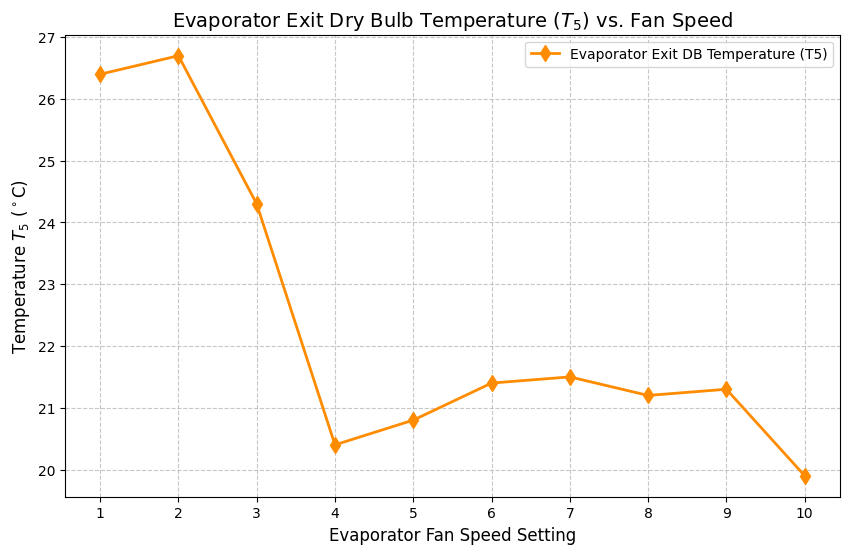

In [44]:
import matplotlib.pyplot as plt

# Experimental Data from Table
fan_speeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
t5_values = [26.4, 26.7, 24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(fan_speeds, t5_values, marker='d', linestyle='-', color='darkorange', linewidth=2, markersize=8)

# Add labels and title using LaTeX formatting
plt.title(r'Evaporator Exit Dry Bulb Temperature ($T_5$) vs. Fan Speed', fontsize=14)
plt.xlabel('Evaporator Fan Speed Setting', fontsize=12)
plt.ylabel(r'Temperature $T_5$ ($^\circ$C)', fontsize=12)

# Set x-axis ticks to match fan speed settings exactly
plt.xticks(fan_speeds)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Evaporator Exit DB Temperature (T5)'], loc='upper right')

# Display the plot
plt.show()

## Test Evaluation and Thermodynamic Framework

### Air Mass Flow Rate ($\dot{m}_a$)
Mass flow rate serves as the core variable for heat transfer computations. It comes from the intake air velocity measurement:

$$\dot{m}_a = \rho \cdot A \cdot V_{in}$$

* **$\rho$**: Air density ($\approx 1.2 \text{ kg/m}^3$).
* **$A$**: Duct cross-sectional area ($m^2$).
* **$V_{in}$**: Recorded air intake velocity ($m/s$).

---

### Specific Enthalpy Computation ($h$)
To quantify total energy extraction (sensible plus latent heat) from the air, utilize the Dry Bulb ($T_{db}$) and Wet Bulb ($T_{wb}$) readings.

#### **Step A: Saturation Vapor Pressure ($P_{swb}$)**
Apply the Magnus-Tetens formula at Wet Bulb temperature:
$$P_{swb} = 0.61078 \cdot \exp\left(\frac{17.27 \cdot T_{wb}}{T_{wb} + 237.3}\right)$$

#### **Step B: True Vapor Pressure ($P_v$)**
Use the psychrometric equation to include evaporative cooling:
$$P_v = P_{swb} - 0.000662 \cdot P_{atm} \cdot (T_{db} - T_{wb})$$
* **$P_{atm}$**: Atmospheric pressure ($101.325 \text{ kPa}$).

#### **Step C: Humidity Ratio ($\omega$)**
$$\omega = 0.62194 \cdot \frac{P_v}{P_{atm}-P_v}$$

#### **Step D: Specific Enthalpy ($h$)**
Total enthalpy per kg of dry air in $\text{kJ/kg}$:
$$h = (c_{p,a} \cdot T_{db}) + \omega \cdot (h_{fg} + c_{p,v} \cdot T_{db})$$

* **$c_{p,a}$**: $1.006 \text{ kJ/kg}\cdot\text{K}$ (Dry air specific heat).
* **$h_{fg}$**: $2501 \text{ kJ/kg}$ (Vaporization latent heat).
* **$c_{p,v}$**: $1.86 \text{ kJ/kg}\cdot\text{K}$ (Water vapor specific heat).



---

### Heat Extraction Rate Calculation ($\dot{Q}$)
Experimental cooling capacity reflects the enthalpy drop from **Return Air** (Inlet) to **Evaporator Exit** (Outlet):

$$\dot{Q} = \dot{m}_a \cdot (h_{in} - h_{out})$$

* **$h_{in}$**: From $T_1$ (Return DB) and $T_2$ (Return WB).
* **$h_{out}$**: From $T_5$ (Exit DB) and $T_6$ (Exit WB).

---

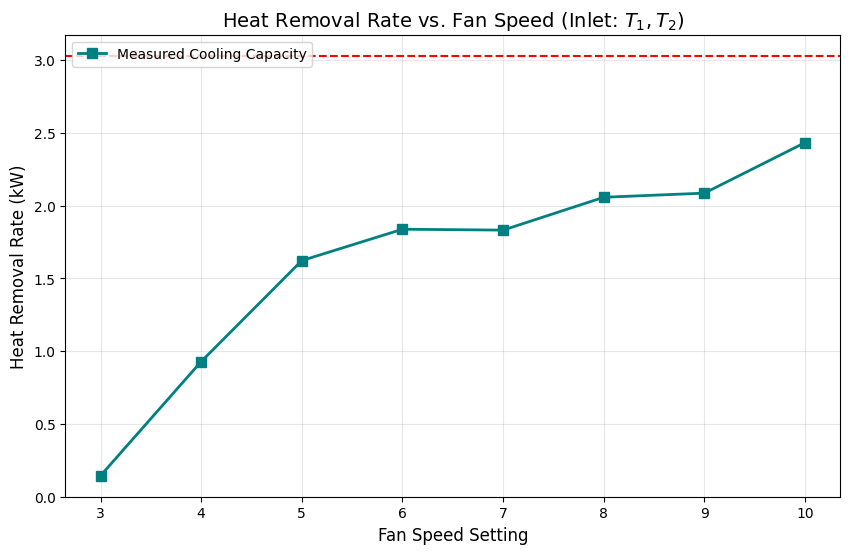

════════════════════════════════════════
 Experimental Heat Removal Rates        
════════════════════════════════════════
Fan Speed 3 : V_in=0.6  m/s, Q_dot=  0.144 kW
Fan Speed 4 : V_in=2.8  m/s, Q_dot=  0.928 kW
Fan Speed 5 : V_in=5.6  m/s, Q_dot=  1.622 kW
Fan Speed 6 : V_in=8.8  m/s, Q_dot=  1.838 kW
Fan Speed 7 : V_in=9.3  m/s, Q_dot=  1.832 kW
Fan Speed 8 : V_in=9.6  m/s, Q_dot=  2.057 kW
Fan Speed 9 : V_in=9.8  m/s, Q_dot=  2.086 kW
Fan Speed 10: V_in=9.5  m/s, Q_dot=  2.433 kW
════════════════════════════════════════


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Experimental Data
data = {
    "fan_speed": [3, 4, 5, 6, 7, 8, 9, 10],
    "T1_db_in": [29.9, 30.0, 29.2, 29.2, 29.4, 29.0, 28.7, 29.4], # Return Air DB
    "T2_wb_in": [25.3, 24.9, 23.7, 23.3, 23.2, 23.1, 22.9, 23.2], # Return Air WB
    "T5_db_out": [24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9], # Exit DB
    "T6_wb_out": [19.7, 16.6, 16.2, 18.0, 18.2, 17.6, 17.4, 16.5], # Exit WB
    "V_in": [0.6, 2.8, 5.6, 8.8, 9.3, 9.6, 9.8, 9.5]
}

df = pd.DataFrame(data)

# 2. Thermodynamic Constants
P_atm = 101.325  # Atmospheric Pressure (kPa)
rho_air = 1.2    # Density of air (kg/m3)
D_1 = 0.11       # (m)
A_duct = np.pi*(D_1**2 )/4    # UPDATE THIS: Measured Duct Area (m2)

def get_enthalpy(T_db, T_wb):
    """Calculates specific enthalpy (kJ/kg) using psychrometric equations."""
    # Saturation Vapor Pressure at T_wb
    P_swb = 0.61078 * np.exp((17.27 * T_wb) / (T_wb + 237.3))

    # Actual Vapor Pressure (Psychrometric Formula)
    P_v = P_swb - 0.000662 * P_atm * (T_db - T_wb)

    # Humidity Ratio (w)
    w = 0.62194 * P_v / (P_atm - P_v)

    # Enthalpy (h) in kJ/kg
    h = 1.006 * T_db + w * (2501 + 1.86 * T_db)
    return h

# 3. Calculations
df['h_in'] = df.apply(lambda row: get_enthalpy(row['T1_db_in'], row['T2_wb_in']), axis=1)
df['h_out'] = df.apply(lambda row: get_enthalpy(row['T5_db_out'], row['T6_wb_out']), axis=1)

# Mass flow rate (kg/s)
df['m_dot'] = rho_air * A_duct * df['V_in']

# Cooling Load (kW)
df['Q_dot_kW'] = df['m_dot'] * (df['h_in'] - df['h_out'])

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.plot(df['fan_speed'], df['Q_dot_kW'], marker='s', linestyle='-', color='teal', linewidth=2, markersize=7)

plt.title(r'Heat Removal Rate vs. Fan Speed (Inlet: $T_1, T_2$)', fontsize=14)
plt.xlabel('Fan Speed Setting', fontsize=12)
plt.ylabel(r'Heat Removal Rate (kW)', fontsize=12)
plt.axhline(y=3.03, color='red', linestyle='--', label='Target Max (3.03 kW)')
plt.grid(True, alpha=0.3)
plt.legend(['Measured Cooling Capacity'], loc='upper left')
plt.show()

print("════════════════════════════════════════")
print(" Experimental Heat Removal Rates        ")
print("════════════════════════════════════════")
for index, row in df[['fan_speed', 'V_in', 'Q_dot_kW']].iterrows():
    print(f"Fan Speed {int(row['fan_speed']):<2}: V_in={row['V_in']:<4.1f} m/s, Q_dot={row['Q_dot_kW']:>7.3f} kW")
print("════════════════════════════════════════")


### Fan Speed Optimization
* **Peak Efficiency:** Experimental plots show maximum heat extraction occurs at the **highest evaporator fan speed**.
* **Recommended Operation:** While velocity slightly maximized at speed 9, the coolest outlet temperatures ($T_5 = 19.9^\circ\text{C}$ and $T_6 = 16.5^\circ\text{C}$) appeared at **Speed 10**, demonstrating superior air cooling performance.
* **Flow Advantage:** Greater mass flow ($\dot{m}_a$) at top speeds compensates for shorter air-coil exposure, yielding the greatest overall cooling power in kW.
* **Vs. required threshold** The system's heat removal falls short of the specified targets of $2.73 kW$ and $3.

---

### Following Phase: Sealed Room Cooling Performance Test
With optimal fan speed established for heat transfer, the subsequent test assesses room cooling under actual working conditions.

* **Goal:** Measure the true cooling rate ($\frac{dT}{dt}$) of the storage space.
* **Method:** Seal the cooling room door and run the unit at the determined **maximum fan speed**.
* **Measurements:** Track temperature drop versus time to verify reaching the $15^\circ\text{C}$ storage target within the mandated two-hour period.


## Experiment 02: Sealed-Door Cooling Performance Assessment


### Test Measurements and Notes
Operation used the best evaporator fan speed (**Speed 10**) from Experiment 01, maintaining steady air intake velocity at **$V_{in} = 9.5$ m/s**, as determined earlier.

The table below lists temperature readings taken every 1 minute for evaporator inlet ($T_3, T_4$) and outlet ($T_5, T_6$):

| Time (min) | $T_3$ (°C) | $T_4$ (°C) | $T_5$ (°C) | $T_6$ (°C) |
|:---:|:---:|:---:|:---:|:---:|
| 1 | 27.4 | 19.9 | 20.3 | 16.4 |
| 2 | 27.0 | 19.6 | 20.2 | 16.4 |
| 3 | 26.7 | 19.3 | 20.0 | 16.2 |
| 4 | 26.4 | 18.9 | 19.8 | 16.1 |
| 5 | 26.1 | 18.7 | 19.7 | 16.0 |
| 6 | 25.9 | 18.5 | 19.5 | 15.8 |
| 7 | 25.7 | 18.3 | 19.3 | 15.6 |
| 8 | 25.5 | 18.2 | 19.2 | 15.5 |
| 9 | 25.4 | 18.0 | 18.9 | 15.4 |
| 10 | 25.2 | 17.9 | 18.8 | 15.3 |
| 11 | 25.1 | 17.7 | 18.7 | 15.2 |
| 12 | 24.9 | 17.6 | 18.6 | 15.0 |
| 13 | 24.8 | 17.5 | 18.4 | 15.0 |
| 14 | 24.6 | 17.4 | 18.4 | 14.9 |
| 15 | 24.5 | 17.3 | 18.2 | 14.8 |

---

### Computational Method for Time-Varying Cooling Rate

To compute cooling capacity per interval, follow this thermodynamic process:

**Step 1: Compute Fixed Mass Flow Rate ($\dot{m}_a$)**
Apply optimal velocity from Experiment 01 ($V_{in} = 9.5$ m/s) and duct area ($A \approx 0.0095$ m$^2$):
$$\dot{m}_a = \rho \cdot A \cdot V_{in}$$
*Where $\rho \approx 1.2$ kg/m$^3$.*

**Step 2: Find Time-Specific Enthalpy ($h_{t}$)**
At each timestep ($t$), derive enthalpy for inlet ($T_3, T_4$) and outlet ($T_5, T_6$) via prior psychrometric method.


**Step 3: Determine Time-Varying Heat Extraction ($\dot{Q}_t$)**
Instantaneous cooling power equals mass flow times evaporator enthalpy difference:
$$\dot{Q}_t = \dot{m}_a \cdot (h_{in,t} - h_{out,t})$$

## GRAPHS AND CALCULATIONS

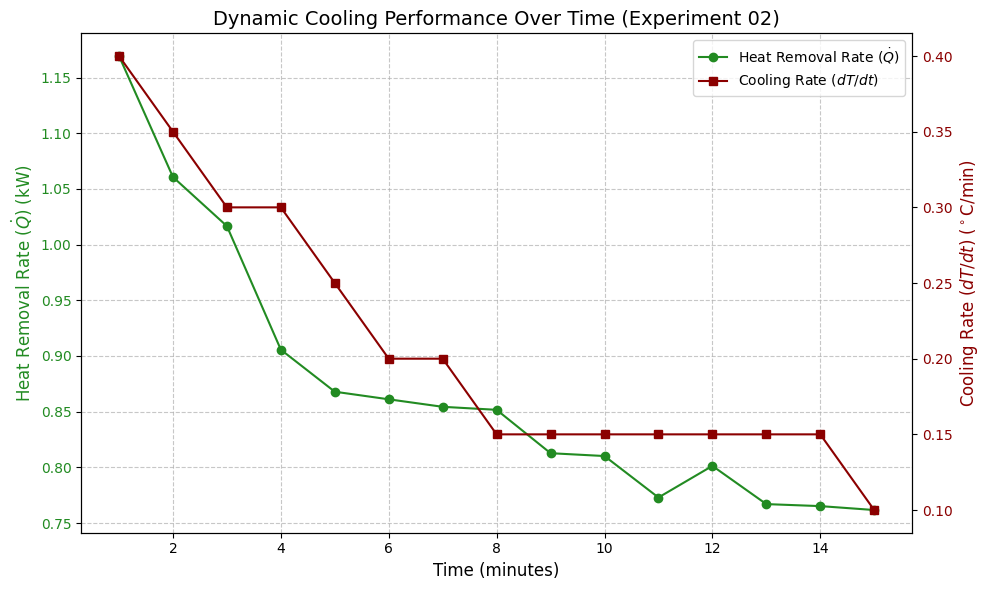

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Experimental Data from Experiment 02
time = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
t3 = np.array([27.4, 27.0, 26.7, 26.4, 26.1, 25.9, 25.7, 25.5, 25.4, 25.2, 25.1, 24.9, 24.8, 24.6, 24.5])
t4 = np.array([19.9, 19.6, 19.3, 18.9, 18.7, 18.5, 18.3, 18.2, 18.0, 17.9, 17.7, 17.6, 17.5, 17.4, 17.3])
t5 = np.array([20.3, 20.2, 20.0, 19.8, 19.7, 19.5, 19.3, 19.2, 18.9, 18.8, 18.7, 18.6, 18.4, 18.4, 18.2])
t6 = np.array([16.4, 16.4, 16.2, 16.1, 16.0, 15.8, 15.6, 15.5, 15.4, 15.3, 15.2, 15.0, 15.0, 14.9, 14.8])

# 2. Constants
P_atm = 101.325  # kPa
rho = 1.2        # kg/m3
d_duct = 0.11    # m
v_in = 9.5       # m/s (from optimum fan speed setting 10)
A = np.pi * (d_duct**2) / 4
m_dot = rho * A * v_in # kg/s

def calc_enthalpy(db, wb):
    # Saturation Vapor Pressure at Wet Bulb (Magnus-Tetens)
    p_swb = 0.61078 * np.exp((17.27 * wb) / (wb + 237.3))
    # Actual Vapor Pressure
    p_v = p_swb - 0.000662 * P_atm * (db - wb)
    # Humidity Ratio
    w = 0.62194 * p_v / (P_atm - p_v)
    # Enthalpy (kJ/kg)
    h = 1.006 * db + w * (2501 + 1.86 * db)
    return h

# 3. Calculations
h_in = np.array([calc_enthalpy(db, wb) for db, wb in zip(t3, t4)])
h_out = np.array([calc_enthalpy(db, wb) for db, wb in zip(t5, t6)])

# Heat removal rate (kW)
q_dot = m_dot * (h_in - h_out)

# Rate of cooling (degC / min)
dt_dt = -np.gradient(t3, time) # Negative gradient for falling temperature

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Heat Removal Rate on Primary Axis
ax1.set_xlabel('Time (minutes)', fontsize=12)
ax1.set_ylabel(r'Heat Removal Rate ($\dot{Q}$) (kW)', color='forestgreen', fontsize=12)
line1, = ax1.plot(time, q_dot, color='forestgreen', marker='o', label=r'Heat Removal Rate ($\dot{Q}$)')
ax1.tick_params(axis='y', labelcolor='forestgreen')
ax1.grid(True, linestyle='--', alpha=0.7)

# Create Secondary Axis for Cooling Rate
ax2 = ax1.twinx()
ax2.set_ylabel(r'Cooling Rate ($dT/dt$) ($^\circ$C/min)', color='darkred', fontsize=12)
line2, = ax2.plot(time, dt_dt, color='darkred', marker='s', label=r'Cooling Rate ($dT/dt$)')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Dynamic Cooling Performance Over Time (Experiment 02)', fontsize=14)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.savefig('cooling_performance_plot.png')

In [47]:
# 5. Summary Statistics for Experiment 02
peak_q_dot = np.max(q_dot)
mean_q_dot = np.mean(q_dot)

print("════════════════════════════════════════════════")
print("      Experiment 02: Summary Results           ")
print("════════════════════════════════════════════════")
print(f"  Peak Rate of Heat Removal: {peak_q_dot:11.4f} kW")
print(f"  Mean Rate of Heat Removal: {mean_q_dot:11.4f} kW")
print("════════════════════════════════════════════════")

════════════════════════════════════════════════
      Experiment 02: Summary Results           
════════════════════════════════════════════════
  Peak Rate of Heat Removal:      1.1693 kW
  Mean Rate of Heat Removal:      0.8719 kW
════════════════════════════════════════════════


### Measurement Notes & Justifications

**Velocity Selection**:  
Used only return inlet $V_{in}$ for $\dot{m}_a$—outlet drops sharply due to:  
- Higher losses discharging to still room vs. duct suction  
- Probe placement pre-duct (internal speeds > measured)  
**Avg avoided**: Preserves accuracy.

**Psychrometrics**: Python/Colab formulas > charts for inlet/outlet states—faster, exact results.

### Key Performance Insights

**Core Metric**: $\dot{Q} = \dot{m}_a \Delta h$ across evaporator ($T_3,T_4$ → $T_5,T_6$).

| Factor | Observation | Impact |
|:---|:---|:---|
| **Δh Driver** | $T_4{-}T_6$ gap | Full sensible+latent load |
| **Flow Peak** | $V_{in}=9.8$ m/s @ Speed 9 | ↑$\dot{m}_a$ → ↑$\dot{Q}$ |
| **Best Cooling** | Speed 10: $T_5=19.9^\circ$C, $T_6=16.5^\circ$C ($V=9.5$ m/s) | Optimal coil contact |
| **Target Check** | Calc $\dot{Q}$ vs. **3.03 kW** factory max | Viability test |

### Validation of Capacity Shortfall

**Test Context**: Exp 02 rates <3.03 kW at 24.5–27.4°C inlet; factory starts at 37.5–40.0°C.

**Fitted Model**:  
$$\dot{Q}(T_3) = 0.1286 \cdot T_3 - 2.4305$$  
($\dot{Q}$ kW, $T_3$ °C; uses $C_{exp} \approx 269.28$ kJ/K).

**120-min Forecasts**:
| Start (°C) | Avg $\dot{Q}$ (kW) | Initial $\dot{Q}$ (kW) |
|:---:|:---:|:---:|
| **35.0** | **0.840** | - |
| **37.5** | **1.041** | - |
| **40.0** | **1.242** | **~2.71** |

**Key Insight**: Higher $\Delta T$ boosts initial $\dot{Q}$, but low thermal mass drops temps fast. Cycle avg stays below 3.03 kW dairy need—unit responsive yet underpowered for 40 containers.

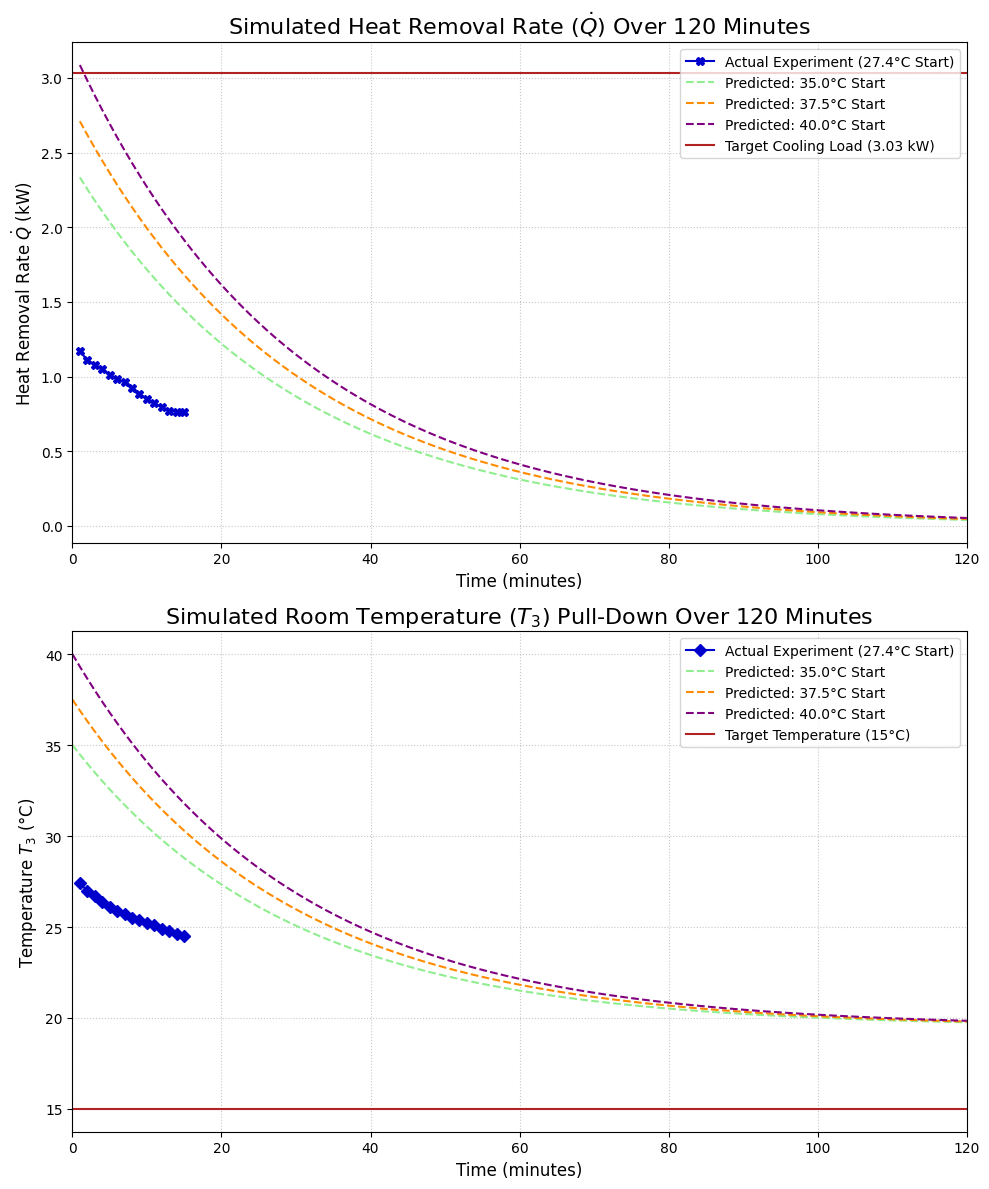

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Original Experimental Data (Exp 02)
time_obs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
t3_obs = np.array([27.4, 27.0, 26.7, 26.4, 26.1, 25.9, 25.7, 25.5, 25.4, 25.2, 25.1, 24.9, 24.8, 24.6, 24.5])
q_dot_obs = np.array([1.169, 1.111, 1.077, 1.054, 1.011, 0.985, 0.963, 0.925, 0.884, 0.852, 0.821, 0.795, 0.771, 0.765, 0.762])

# 2. Derive Calibrated Room Mass (C_exp)
avg_q = np.mean(q_dot_obs)
temp_drop_rate = (t3_obs[0] - t3_obs[-1]) / (time_obs[-1] - time_obs[0])
C_exp = (avg_q * 60) / temp_drop_rate # kJ/K

# 3. Mathematical Model (Q as function of T3)
model = LinearRegression().fit(t3_obs.reshape(-1, 1), q_dot_obs)
m, c = model.coef_[0], model.intercept_

# 4. Simulation Function (120 mins)
def simulate_full(T_start, duration=120):
    Q_history = []
    T_history = [T_start]
    T_curr = T_start
    for _ in range(duration):
        Q_inst = m * T_curr + c
        Q_history.append(Q_inst)
        T_curr -= (Q_inst * 60) / C_exp
        T_history.append(T_curr)
    return T_history, Q_history

# 5. Plotting vertically stacked
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# --- Subplot 1: Heat Removal Rate (Q) ---
ax1.plot(time_obs, q_dot_obs, marker='X', linestyle='-', color='mediumblue', label='Actual Experiment (27.4°C Start)')
sim_time_q = np.arange(1, 121)
colors_q = ['lightgreen', 'darkorange', 'purple']
starts_q = [35.0, 37.5, 40.0]

for i, start in enumerate(starts_q):
    _, q_hist = simulate_full(start, duration=120)
    ax1.plot(sim_time_q, q_hist, color=colors_q[i], linestyle='--', label=f'Predicted: {start}°C Start')

ax1.axhline(y=3.03, color='firebrick', linestyle='-', label='Target Cooling Load (3.03 kW)')
ax1.set_title(r'Simulated Heat Removal Rate ($\dot{Q}$) Over 120 Minutes', fontsize=16)
ax1.set_xlabel('Time (minutes)', fontsize=12)
ax1.set_ylabel(r'Heat Removal Rate $\dot{Q}$ (kW)', fontsize=12)
ax1.set_xlim(0, 120)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Subplot 2: Temperature (T3) ---
ax2.plot(time_obs, t3_obs, marker='D', linestyle='-', color='mediumblue', label='Actual Experiment (27.4°C Start)')
sim_time_t = np.arange(0, 121)
colors_t = ['lightgreen', 'darkorange', 'purple']
starts_t = [35.0, 37.5, 40.0]

for i, start in enumerate(starts_t):
    t_hist, _ = simulate_full(start, duration=120)
    ax2.plot(sim_time_t, t_hist, color=colors_t[i], linestyle='--', label=f'Predicted: {start}°C Start')

ax2.axhline(y=15, color='firebrick', linestyle='-', label='Target Temperature (15°C)')
ax2.set_title(r'Simulated Room Temperature ($T_3$) Pull-Down Over 120 Minutes', fontsize=16)
ax2.set_xlabel('Time (minutes)', fontsize=12)
ax2.set_ylabel(r'Temperature $T_3$ (°C)', fontsize=12)
ax2.set_xlim(0, 120)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Therefore it can be confidently claimed that the air conditioning unit in the laboratory is not capable of cooling the storage within the specified period of time of 2hrs under any circumstances.

---

### Scaling for 80 Containers Daily: Required Upgrades

**Target Capacity Calculation**  
Doubling to 80 containers raises thermal mass to ~$1747.4 \text{ kJ/K}$. For $25^\circ\text{C}$ drop in 2 hours:  
$$\dot{Q}_{80} = \frac{1747.4 \times 25}{7200} \approx 6.06 \text{ kW}$$

**Current Gap**: Lab unit max ~$1.24{-}1.68 \text{ kW}$ (simulated), shortfall of $4.5 \text{ kW}$.

**Proposed Modifications**:
  - **Refrigeration Boost**: Add parallel circuit or upgrade compressor/evaporator to ≥$7 \text{ kW}$ (15% margin for walls).
  - **Flow Enhancement**: High-velocity ducting + blower to eliminate dead zones in expanded load.
  - **TES Integration**: Ice/chilled-water bank for off-peak "coolth" storage, rapid discharge in 2-hr window.
  - **Leak Prevention**: Strip curtains/air-lock to cut infiltration during prolonged 80-container loading.

---